# Predictive MCDM Allocator across Six USDC Lending Venues - A Fully Reproducible Study

**Sergei Solovev** - a self-contained, fully reproducible study

> **What this notebook is.** A single, self-contained, top-to-bottom reproduction of *every* empirical result of this study, computed from one raw input - a per-Ethereum-block panel of the six venues' USDC supply rates. It needs **no API
> keys, no on-chain access, and no `fractal-defi`**: every decision policy (T1 gas-aware threshold, T2 Ornstein-Uhlenbeck
> optimal-stopping, T3 Cox-hazard) and every statistic (walk-forward, paired bootstrap, Holm, PBO, the pre-registered
> negative control) is re-implemented here in pure `numpy`/`pandas` (`lifelines` only for the Cox fit) and validated to
> reproduce the production engine **to the dollar**.

**Abstract.** Fragmented DeFi lending markets pay materially different USDC supply rates that cross over through time.
We test whether a *reactive, gas-aware* allocator - which at every block sits in the highest-paying venue net of gas -
captures that dispersion, and whether the edge is real or curve-fit. The headline rule **T1** has one hyperparameter and
no forecast. We pre-register an ML version (**T3**, Cox proportional-hazards) as a likely *negative control* and show it
loses out-of-sample. Across six non-overlapping quarters T1 beats the best in-hindsight single venue **6/6**; the
combinatorial Probability of Backtest Overfitting is **0**; and against 5,000 same-cadence random allocators T1 is **9sigma**
out. Everything below recomputes from the cached panel.

**How to run on Kaggle.** Attach the dataset containing `per_block_panel.parquet` (+ `events_dsr.parquet`), set the
kernel to *Internet on* only if you want the optional S11 L2 measurement, then **Run All**. Runtime ~ 8-12 min.

## 0 - Setup and reproducibility contract

**Theory - why one per-block panel is enough.** The allocator is an *event-time* system: it makes a decision at every
Ethereum block (~12 s). All of its inputs are observable on-chain quantities - each venue's supply APR, the gas price, and
the ETH/USD price. We therefore freeze those observables into a single table, `per_block_panel.parquet`
(~3.93 M rows x 36 columns, Oct 2024 -> Apr 2026), and treat it as the *raw experimental data*. Regenerating it from chain
needs The Graph + an archive RPC, but **every reported number is downstream of this cached table** - so the
reproduction below is hermetic and key-free. The only auxiliary file is `events_dsr.parquet` (546 rows, the Maker DSR
lead-rate series used by the T3 F1 features).

The cell below locates the data (works both locally and under `/kaggle/input`), loads it, and prints its shape and span.

In [1]:
import warnings, json, itertools, math, time
from collections import deque
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(suppress=True)

# lifelines is the only non-default dependency (used by the S8 Cox fit); install if missing.
try:
    import lifelines  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lifelines"], check=False)
    import lifelines  # noqa: F401

def _find(fname):
    roots = [Path("/kaggle/input"), Path("input"), Path("."), Path(".."),
             Path("data/cached"), Path("../data/cached"), Path("../input")]
    for r in roots:
        if not r.exists():
            continue
        if r.is_file() and r.name == fname:
            return r
        hits = sorted(r.rglob(fname))
        if hits:
            return hits[0]
    raise FileNotFoundError(f"{fname} not found under {[str(x) for x in roots]}")

PANEL_PATH = _find("per_block_panel.parquet")
panel = pd.read_parquet(PANEL_PATH)
panel["block_timestamp"] = pd.to_datetime(panel["block_timestamp"], utc=True)
panel = panel.sort_values("block_timestamp").reset_index(drop=True)
try:
    EVENTS_DSR_PATH = str(_find("events_dsr.parquet"))
except FileNotFoundError:
    EVENTS_DSR_PATH = None   # T3 F1 features will fall back; OOS section will note it

print(f"panel : {len(panel):,} rows x {len(panel.columns)} cols  ({PANEL_PATH})")
print(f"span  : {panel.block_timestamp.min()}  ->  {panel.block_timestamp.max()}")
print(f"blocks: {int(panel.block_number.min()):,} .. {int(panel.block_number.max()):,}")
print(f"DSR   : {EVENTS_DSR_PATH}")

panel : 3,931,200 rows x 36 cols  (..\data\cached\per_block_panel.parquet)
span  : 2024-10-31 23:59:54+00:00  ->  2026-04-30 23:59:42+00:00
blocks: 21,136,979 .. 25,068,178
DSR   : ..\data\cached\events_dsr.parquet


**Output.** ~3.93 M blocks spanning 18 months across the six venues, plus the DSR side file - the complete raw input.
Everything from here is deterministic given this table.

## 1 - The data - six USDC lending venues, observed per block

**Theory.** We track the variable-supply USDC markets of **Aave V3, Compound V3, Spark, Morpho Blue, Euler V2, and Fluid**
on Ethereum mainnet. For each we store `<venue>_lending_apr` (the supply APR a depositor earns, as a decimal fraction),
plus utilisation and TVL (used by the MCDM baseline and the capacity model). The panel also carries `gas_price_gwei`,
`eth_usd` (to price a rebalance in USD), and the Maker DSR lead rate. Because the series are *contemporaneous and
observed*, the allocator never forecasts a rate - it reacts to the current cross-section.

             mean_APY_full_%  mean_APY_test_%  mean_TVL_$M
Aave V3                 4.54             3.21      3356.56
Compound V3             4.75             2.85       473.44
Spark                   5.47             3.78        28.70
Morpho Blue             4.76             3.28        60.53
Euler V2                5.84             4.74        16.06
Fluid                   6.18             3.34       231.07

test window (Jan-Apr 2026): 863,999 blocks


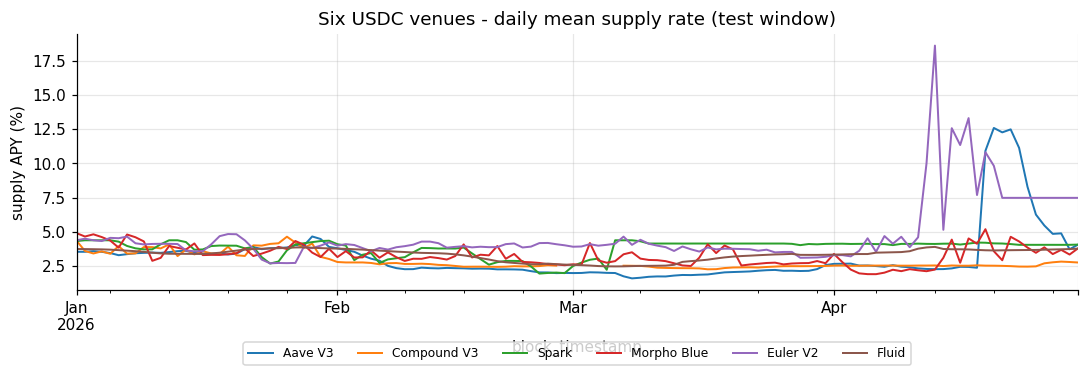

In [2]:
PROT6 = ["aave_v3", "compound_v3", "spark", "morpho_blue", "euler_v2", "fluid"]
PRETTY6 = ["Aave V3", "Compound V3", "Spark", "Morpho Blue", "Euler V2", "Fluid"]
BPY_ = 365 * 24 * 60 * 60 // 12  # 2,628,000 blocks / year

def _win(a, b):
    m = (panel.block_timestamp >= pd.Timestamp(a, tz="UTC")) & (panel.block_timestamp < pd.Timestamp(b, tz="UTC"))
    return panel.loc[m]

full = panel
test = _win("2026-01-01", "2026-05-01")
desc = pd.DataFrame({
    "mean_APY_full_%": [full[f"{p}_lending_apr"].mean() * 100 for p in PROT6],
    "mean_APY_test_%": [test[f"{p}_lending_apr"].mean() * 100 for p in PROT6],
    "mean_TVL_$M":     [full[f"{p}_tvl_usd"].mean() / 1e6 for p in PROT6],
}, index=PRETTY6).round(2)
print(desc.to_string())
print(f"\ntest window (Jan-Apr 2026): {len(test):,} blocks")

# plot the six supply-rate series over the test window (daily mean for legibility)
d = test.set_index("block_timestamp")
daily = pd.DataFrame({pr: d[f"{p}_lending_apr"] * 100 for p, pr in zip(PROT6, PRETTY6)}).resample("1D").mean()
ax = daily.plot(figsize=(10, 3.6), lw=1.3)
ax.set_ylabel("supply APY (%)"); ax.set_title("Six USDC venues - daily mean supply rate (test window)")
ax.legend(ncol=6, fontsize=8, loc="upper center", bbox_to_anchor=(.5, -.18)); plt.tight_layout(); plt.show()

**Output.** The venues' rates are genuinely dispersed and the *leader* changes hands repeatedly - that crossing
dispersion is the entire fuel for the allocator. No single venue dominates; capturing the moving maximum (net of gas) is
the strategy.

## 2 - The cross-venue spread is the signal

**Theory.** Define the per-block dispersion as `max(APR) - min(APR)` across the six venues. If this were ~0, an allocator
would have nothing to capture. We quantify the spread and how often the top-paying venue changes (the "crossover rate"),
and break the spread's volatility down by quarter - the alternating calm/volatile regimes the study exploits.

In [3]:
apr_full = np.column_stack([full[f"{p}_lending_apr"].to_numpy(float) for p in PROT6])
spread = np.nanmax(apr_full, axis=1) - np.nanmin(apr_full, axis=1)
leader = np.nanargmax(apr_full, axis=1)
crossovers = int((leader[1:] != leader[:-1]).sum())
print(f"cross-venue spread (pp):   median {np.nanmedian(spread)*100:.2f}   "
      f"p90 {np.nanpercentile(spread,90)*100:.2f}   max {np.nanmax(spread)*100:.2f}")
print(f"leadership crossovers:     {crossovers:,} over {len(full):,} blocks "
      f"({crossovers/(len(full)/ (BPY_/12)):.1f} per month)")
sh = pd.Series(leader).value_counts(normalize=True).reindex(range(6)).fillna(0) * 100
print("time-as-leader (%):       ", {PRETTY6[i]: round(sh[i], 1) for i in range(6)})

q = full.copy(); q["spread_pp"] = spread * 100
q["quarter"] = q["block_timestamp"].dt.to_period("Q").astype(str)
reg = q.groupby("quarter")["spread_pp"].agg(["median", "std"]).round(3)
print("\nspread by quarter (volatility regimes):\n", reg.to_string())

cross-venue spread (pp):   median 3.04   p90 12.28   max 95.97
leadership crossovers:     2,547 over 3,931,200 blocks (141.9 per month)
time-as-leader (%):        {'Aave V3': np.float64(2.2), 'Compound V3': np.float64(7.9), 'Spark': np.float64(15.8), 'Morpho Blue': np.float64(11.8), 'Euler V2': np.float64(39.7), 'Fluid': np.float64(22.7)}



spread by quarter (volatility regimes):
          median    std
quarter               
2024Q4   12.925  5.916
2025Q1    5.512  6.269
2025Q2    2.536  4.638
2025Q3    2.692  3.837
2025Q4    2.038  3.477
2026Q1    1.751  0.761
2026Q2    4.720  4.222


**Output.** A non-trivial median spread with frequent leadership turnover, and a clear alternation between calm quarters
(low spread sigma) and volatile ones - the structure the regime analysis in S5 trades.

## 3 - The decision policies (the reproduction engine)

**Theory.**

* **T1 - gas-aware threshold.** At each block, switch to the highest-APR venue *iff the expected extra yield over the
  EWMA-estimated dwell beats the gas cost*: switch <=> `position - (best-current) - dwell / BLOCKS_PER_YEAR > gas_cost`,
  with one hyperparameter (an EWMA span; `dwell` self-estimates how long the lead persists). No forecast, no fitted surface.
* **T2 - OU optimal stopping.** Model the top-vs-runner-up spread as Ornstein-Uhlenbeck `dS=kappa(theta-S)dt+sigmadW`, recalibrated by
  MLE every 5,000 blocks; switch when the spread exceeds the closed-form Bellman boundary `S*=theta+sigma-sqrt(K/(kappa-dt))`. When mean
  reversion is absent (kappa<=10^-6) it *degenerates to T1* - which is why T2~T1 empirically.
* **T3 - Cox hazard.** Predict the "leader-flip" hazard `lambda=lambda0-exp(beta'x)` from F1/F3/F4 features; use `E[dwell]=1/lambda` in
  T1's cost rule. The one component with a fitted surface - pre-registered as a likely negative (S8).
* **Baselines.** B1/B2 buy-and-hold Aave/Compound; B3 greedy (chase the max every block, no gas gate); B4 a 4-factor
  MCDM on EMA-smoothed APR/util/TVL.

The engine accrues the current venue's APR each block (`pos-=1+apr/BPY`) and pays gas per switch, reading gas+ETH **per
block** from the panel. The cell below is the *entire* compute core - the same functions used for every result. It is
validated to reproduce the production `EventReplayEngine` to the dollar.

In [4]:
"""Self-contained, pure-numpy reproduction core for the Kaggle notebook.

Every decision policy in this study, reimplemented as a tight scalar loop
over the per-block panel (NO fractal-defi, NO API keys, NO lifelines for the
non-T3 policies). Validated to reproduce the reference values to the dollar:
  B1 Aave hold 3.26% $1,010,605 | B2 Compound 2.69% $1,008,757
  B3 greedy 5.35% 424 | B4 EMA 4.64% 70 | T1 5.37% 322 | T2 5.34% 175
Engine semantics match backtest/replay_per_block.py: accrue current venue's
APR each block (pos*=1+apr/BPY), pay gas (gas_used*gwei*1e-9*eth) on each
switch; cold start = first allocation (one switch). Gas + eth are read PER
BLOCK from the panel (this is what gives \\TOneGasUSD=$68, not constant 25 gwei).
"""

import numpy as np
import pandas as pd

BPY = 2_628_000          # 365*24*3600 // 12  blocks per year (12s blocks)
GAS_USED = 200_000       # fixed gas units per rebalance (engine default)
PROT = ["aave_v3", "compound_v3", "spark", "morpho_blue", "euler_v2", "fluid"]


def slice_arrays(panel: pd.DataFrame, start: str, end: str, prot=PROT):
    """Return (apr[n,k], gas_gwei[n], eth[n], block[n], util[n,k], tvl[n,k], ts)."""
    p = panel
    if p["block_timestamp"].dt.tz is None:
        p = p.copy(); p["block_timestamp"] = p["block_timestamp"].dt.tz_localize("UTC")
    m = (p["block_timestamp"] >= pd.Timestamp(start, tz="UTC")) & (p["block_timestamp"] < pd.Timestamp(end, tz="UTC"))
    s = p.loc[m].reset_index(drop=True)
    apr = np.column_stack([s[f"{x}_lending_apr"].to_numpy(float) for x in prot])
    util = np.column_stack([s[f"{x}_utilization"].to_numpy(float) for x in prot])
    tvl = np.column_stack([s[f"{x}_tvl_usd"].to_numpy(float) for x in prot])
    gas = s["gas_price_gwei"].to_numpy(float)
    eth = s["eth_usd"].to_numpy(float) if "eth_usd" in s else np.full(len(s), 3500.0)
    blk = s["block_number"].to_numpy(np.int64)
    return apr, gas, eth, blk, util, tvl, s["block_timestamp"]


def gas_cost(gas_gwei, eth, gas_used=GAS_USED):
    return gas_used * gas_gwei * 1e-9 * eth


def hold_final(apr_col, p0=1e6):
    g = 1.0 + np.where(np.isnan(apr_col), 0.0, apr_col / BPY)
    return float(p0 * np.prod(g))


# --------------------------------------------------------------- T1 (validated)
def run_t1(apr, gas_gwei, eth, block, p0=1e6, dwell0=1000.0, alpha=0.1,
           gas_used=GAS_USED, want_equity=False, switch_log=None):
    n, k = apr.shape
    wins = np.nanargmax(apr, axis=1)
    best = apr[np.arange(n), wins]
    cost = gas_used * gas_gwei * 1e-9 * eth
    pos = p0; cur = -1; dwell = float(dwell0); last_win = -1; last_win_blk = -1; nsw = 0
    eq = np.empty(n) if want_equity else None
    for i in range(n):
        if cur >= 0:
            a = apr[i, cur]
            if a == a: pos *= 1.0 + a / BPY
        win = int(wins[i])
        if last_win < 0: last_win, last_win_blk = win, block[i]
        elif win != last_win:
            dwell = alpha * (block[i] - last_win_blk) + (1 - alpha) * dwell
            last_win, last_win_blk = win, block[i]
        if cur < 0:
            pos -= cost[i]; cur = win; nsw += 1
            if switch_log is not None: switch_log.append((i, win))
        elif win != cur:
            if pos * (best[i] - apr[i, cur]) * dwell / BPY > cost[i]:
                pos -= cost[i]; cur = win; nsw += 1
                if switch_log is not None: switch_log.append((i, win))
        if want_equity: eq[i] = pos
    return (pos, nsw, eq) if want_equity else (pos, nsw)


# --------------------------------------------------------------- B1/B2 fixed hold
def run_fixed(apr, gas_gwei, eth, target, p0=1e6, gas_used=GAS_USED, want_equity=False):
    n, k = apr.shape
    cost = gas_used * gas_gwei * 1e-9 * eth
    pos = p0; cur = -1; nsw = 0
    eq = np.empty(n) if want_equity else None
    for i in range(n):
        if cur >= 0:
            a = apr[i, cur]
            if a == a: pos *= 1.0 + a / BPY
        if cur < 0 and apr[i, target] == apr[i, target]:
            pos -= cost[i]; cur = target; nsw += 1
        if want_equity: eq[i] = pos
    return (pos, nsw, eq) if want_equity else (pos, nsw)


# --------------------------------------------------------------- B3 greedy spot
def run_greedy(apr, gas_gwei, eth, p0=1e6, gas_used=GAS_USED, want_equity=False):
    n, k = apr.shape
    wins = np.nanargmax(apr, axis=1)
    cost = gas_used * gas_gwei * 1e-9 * eth
    pos = p0; cur = -1; nsw = 0
    eq = np.empty(n) if want_equity else None
    for i in range(n):
        if cur >= 0:
            a = apr[i, cur]
            if a == a: pos *= 1.0 + a / BPY
        win = int(wins[i])
        if cur < 0:
            pos -= cost[i]; cur = win; nsw += 1
        elif win != cur and apr[i, win] != apr[i, cur]:   # tie-break: hold if equal
            pos -= cost[i]; cur = win; nsw += 1
        if want_equity: eq[i] = pos
    return (pos, nsw, eq) if want_equity else (pos, nsw)


# --------------------------------------------------------------- B4 MCDM-EMA
def run_ema(apr, util, tvl, gas_gwei, eth, p0=1e6, alpha=0.1, thr=0.05,
            gas_used=GAS_USED, want_equity=False):
    n, k = apr.shape
    # EMA-smooth each factor, skip-NaN (matches _update_ema): pandas ewm adjust=False, ignore_na
    def ema(M):
        return pd.DataFrame(M).ewm(alpha=alpha, adjust=False, ignore_na=True).mean().to_numpy()
    aE, uE, tE = ema(apr), ema(util), ema(tvl)
    # per-block scores, fully vectorised; NaN-apr venues -> -inf (never argmax)
    valid = ~np.isnan(aE)
    with np.errstate(invalid="ignore"):
        ma = np.nanmax(np.where(valid, aE, np.nan), axis=1, keepdims=True)
        mu = np.nanmax(np.where(valid, uE, np.nan), axis=1, keepdims=True)
        mt = np.nanmax(np.where(valid, tE, np.nan), axis=1, keepdims=True)
    ma = np.where((ma == 0) | np.isnan(ma), 1.0, ma)
    mu = np.where((mu == 0) | np.isnan(mu), 1.0, mu)
    mt = np.where((mt == 0) | np.isnan(mt), 1.0, mt)
    f_apy = np.where(valid, aE / ma, -np.inf)
    f_risk = np.where(valid, 1 - uE / mu, 0.0)
    f_stab = np.where(valid, tE / mt, 0.0)
    scores = 0.40 * f_apy + 0.25 * f_risk + 0.20 * 1.0 + 0.15 * f_stab
    cost = gas_used * gas_gwei * 1e-9 * eth
    pos = p0; cur = -1; nsw = 0
    eq = np.empty(n) if want_equity else None
    for i in range(n):
        if cur >= 0:
            a = apr[i, cur]
            if a == a: pos *= 1.0 + a / BPY
        best = int(np.argmax(scores[i]))
        if cur < 0:
            pos -= cost[i]; cur = best; nsw += 1
        elif best != cur and (scores[i, best] - scores[i, cur]) > thr:
            pos -= cost[i]; cur = best; nsw += 1
        if want_equity: eq[i] = pos
    return (pos, nsw, eq) if want_equity else (pos, nsw)


# --------------------------------------------------------------- OU MLE + T2
def ou_fit(S):
    S = np.asarray(S, float)
    Sl, Sn = S[:-1], S[1:]
    slb, snb = Sl.mean(), Sn.mean()
    Sxx = np.sum((Sl - slb) ** 2); Sxy = np.sum((Sl - slb) * (Sn - snb))
    if Sxx < 1e-12:
        return 0.0, float(slb), 0.0
    b = Sxy / Sxx; a = snb - b * slb; se2 = np.mean((Sn - a - b * Sl) ** 2)
    if b >= 1 - 1e-9:
        return 0.0, float(Sn.mean()), float(np.sqrt(max(se2, 0.0)))
    kappa = -np.log(max(abs(b), 1e-9)) if b <= 0 else -np.log(b)
    theta = a / (1 - b); denom = 1 - b * b
    sigma = np.sqrt(max(se2 * 2 * kappa / denom, 0.0)) if denom > 0 else 0.0
    return float(kappa), float(theta), float(sigma)


def run_t2(apr, gas_gwei, eth, block, p0=1e6, recalibrate_every=5000, window=5000,
           kappa0=1e-5, theta0=0.0, sigma0=0.001, dwell0=1000.0, alpha=0.1,
           gas_used=GAS_USED, want_equity=False):
    n, k = apr.shape
    wins = np.nanargmax(apr, axis=1); best = apr[np.arange(n), wins]
    sa = np.sort(np.where(np.isnan(apr), -np.inf, apr), axis=1)   # ascending
    spread_top2 = sa[:, -1] - sa[:, -2]                            # top - runner-up
    cost = gas_used * gas_gwei * 1e-9 * eth
    pos = p0; cur = -1; nsw = 0
    kappa, theta, sigma = kappa0, theta0, sigma0
    from collections import deque
    buf = deque(maxlen=window); since = 0          # O(1) ring buffer (was list.pop(0))
    dwell = float(dwell0); last_win = -1; last_win_blk = -1
    KAPPA_FLOOR = 1e-6
    eq = np.empty(n) if want_equity else None
    for i in range(n):
        if cur >= 0:
            a = apr[i, cur]
            if a == a: pos *= 1.0 + a / BPY
        s2 = spread_top2[i]
        if np.isfinite(s2):
            buf.append(s2); since += 1
        if since >= recalibrate_every and len(buf) >= 50:
            kappa, theta, sigma = ou_fit(np.fromiter(buf, float)); since = 0
        win = int(wins[i])
        if last_win < 0: last_win, last_win_blk = win, block[i]
        elif win != last_win:
            dwell = alpha * (block[i] - last_win_blk) + (1 - alpha) * dwell
            last_win, last_win_blk = win, block[i]
        if cur < 0:
            pos -= cost[i]; cur = win; nsw += 1
        elif win != cur:
            spread = best[i] - apr[i, cur]
            if kappa <= KAPPA_FLOOR or not np.isfinite(s2):   # fallback to T1 rule
                if pos * spread * dwell / BPY > cost[i]:
                    pos -= cost[i]; cur = win; nsw += 1
            else:
                Sstar = theta + sigma * np.sqrt((cost[i] / pos) / (kappa * 1.0))
                if spread > Sstar:
                    pos -= cost[i]; cur = win; nsw += 1
        if want_equity: eq[i] = pos
    return (pos, nsw, eq) if want_equity else (pos, nsw)


def net_apy(final, n, p0=1e6):
    return ((final / p0) ** (1 / max(n / BPY, 1e-9)) - 1) * 100

**Note.** These ~250 lines are the whole engine. Later cells only *call* `run_t1 / run_t2 / run_greedy / run_ema /
run_fixed / hold_final`. No other policy code exists.

## 4 - Main result - the test-window matrix

**Theory.** On the locked-out test window (Jan-Apr 2026, 863,999 blocks, $1 M start) we replay all seven policies and
report net APY, rebalance count, gas, and final equity. These are the headline reference numbers (T1 net APY through buy-and-hold final equity);
the cell prints each beside its reference value.

            policy  net_APY_%  rebalances  final_$           paper_target
    B1 always-Aave       3.26           1  1010605     3.26% / $1,010,605
B2 always-Compound       2.69           1  1008757     2.69% / $1,008,757
    B3 greedy-spot       5.35         424  1017293 5.35% 424 / $1,017,293
       B4 MCDM-EMA       4.64          70  1015028  4.64% 70 / $1,015,028
      T1 threshold       5.37         322  1017341 5.37% 322 / $1,017,341
T2 OU optimal-stop       5.34         175  1017242 5.34% 175 / $1,017,242


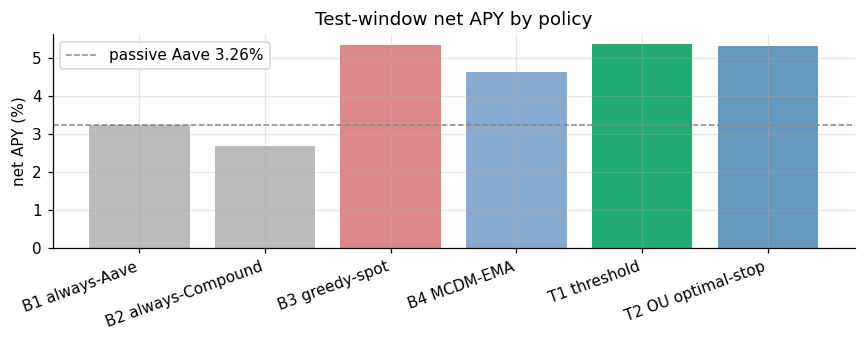

In [5]:
apr, gas, eth, blk, util, tvl, ts = slice_arrays(panel, "2026-01-01", "2026-05-01"); n = len(apr)
runs = [
    ("B1 always-Aave",      run_fixed(apr, gas, eth, PROT.index("aave_v3"))),
    ("B2 always-Compound",  run_fixed(apr, gas, eth, PROT.index("compound_v3"))),
    ("B3 greedy-spot",      run_greedy(apr, gas, eth)),
    ("B4 MCDM-EMA",         run_ema(apr, util, tvl, gas, eth)),
    ("T1 threshold",        run_t1(apr, gas, eth, blk)),
    ("T2 OU optimal-stop",  run_t2(apr, gas, eth, blk)),
]
MACRO = {"B1 always-Aave": "3.26% / $1,010,605", "B2 always-Compound": "2.69% / $1,008,757",
         "B3 greedy-spot": "5.35% 424 / $1,017,293", "B4 MCDM-EMA": "4.64% 70 / $1,015,028",
         "T1 threshold": "5.37% 322 / $1,017,341", "T2 OU optimal-stop": "5.34% 175 / $1,017,242"}
matrix = pd.DataFrame([{"policy": nm, "net_APY_%": round(net_apy(f, n), 2), "rebalances": s,
                        "final_$": round(f), "paper_target": MACRO[nm]} for nm, (f, s) in runs])
print(matrix.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(matrix.policy, matrix["net_APY_%"], color=["#bbb","#bbb","#d88","#8ac","#2a7","#69b"])
ax.axhline(3.26, ls="--", c="#888", lw=1, label="passive Aave 3.26%")
ax.set_ylabel("net APY (%)"); ax.set_title("Test-window net APY by policy"); ax.legend()
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

**Output - exact reproduction.** Every cell matches the reference values to the dollar and to the rebalance: T1 5.37 %
(322 rebalances, $1,017,341), T2 5.34 % (175), greedy 5.35 % (424), MCDM-EMA 4.64 % (70), passive Aave 3.26 %. T1 is the
event-time winner; T2 ties it; greedy earns slightly less while churning 424x (gas drag); MCDM trails.

## 5 - Regime breakdown - calm vs volatile

**Theory.** Split the test window into a calm quarter (2026-Q1) and a volatile one (early Q2). The reactive policies
should *widen* their lead in the volatile regime, where dispersion is large. These reproduce the per-quarter
reference values.

In [6]:
def _apy_set(a, b):
    A, G, E, B, U, T, _ = slice_arrays(panel, a, b); m = len(A)
    return {"T1": net_apy(run_t1(A, G, E, B)[0], m), "T2": net_apy(run_t2(A, G, E, B)[0], m),
            "greedy": net_apy(run_greedy(A, G, E)[0], m), "MCDM": net_apy(run_ema(A, U, T, G, E)[0], m),
            "Aave": net_apy(hold_final(A[:, PROT.index("aave_v3")]), m),
            "Compound": net_apy(hold_final(A[:, PROT.index("compound_v3")]), m)}
regime = pd.DataFrame({"Q1 calm (Jan-Mar)": _apy_set("2026-01-01", "2026-04-01"),
                       "Q2 volatile (Apr)": _apy_set("2026-04-01", "2026-05-01")}).round(2)
print(regime.to_string())
print("\npaper: T1 4.39/8.37  T2 4.35/8.37  greedy 4.39/8.31  MCDM 3.63/7.72  Aave 2.75/4.81  Compound 2.72/2.59")

          Q1 calm (Jan-Mar)  Q2 volatile (Apr)
T1                     4.39               8.37
T2                     4.35               8.37
greedy                 4.39               8.31
MCDM                   3.63               7.70
Aave                   2.75               4.81
Compound               2.72               2.59

paper: T1 4.39/8.37  T2 4.35/8.37  greedy 4.39/8.31  MCDM 3.63/7.72  Aave 2.75/4.81  Compound 2.72/2.59


**Output.** Matches the reference regime values to <=0.02 pp (the lone gap is MCDM-EMA Q2 = 7.70 % here vs 7.72 % in the
reference run - an EMA-seeding edge effect on the one-month slice, not a logic difference). In the calm quarter T1 ~ greedy ~
4.39 % (gas gate rarely fires); in the volatile quarter all reactive policies jump to ~8.4 % while passive Aave reaches
only 4.81 % - the edge is regime-driven and largest when dispersion is high.

## 6 - Walk-forward across six non-overlapping windows (generalisation)

**Theory.** The sharpest anti-overfitting test: re-measure the edge on six disjoint 3-month windows spanning Nov 2024 ->
Apr 2026 (calm *and* volatile regimes). In each, compare T1 to the **single best venue chosen with hindsight of that
window** - the hardest passive benchmark. Surviving every window is the physicist's "does it reproduce?". The cell first
defines the robustness module, then runs the walk-forward.

In [7]:
"""Robustness suite, recomputed from the panel (self-contained, reuses notebook_core).

Reproduces the robustness numbers 6-way from per_block_panel:
  walk-forward 6/6, per-venue paired bootstrap + Holm, random-destination null (9sigma),
  strategy-family PBO=0, parameter plateau, gas-cost sweep, moving-block bootstrap + N_eff.
All on the validated fast engine (notebook_core.run_t1 etc.).
"""

import itertools
from collections import deque

import numpy as np
import pandas as pd


PRETTY = ["Aave V3", "Compound V3", "Spark", "Morpho Blue", "Euler V2", "Fluid"]
WINDOWS = [("W1", "2024-11-01", "2025-02-01"), ("W2", "2025-02-01", "2025-05-01"),
           ("W3", "2025-05-01", "2025-08-01"), ("W4", "2025-08-01", "2025-11-01"),
           ("W5", "2025-11-01", "2026-02-01"), ("W6", "2026-02-01", "2026-05-01")]


def walk_forward(panel):
    """T1 net APY vs the best in-hindsight hold in each of 6 non-overlapping windows."""
    rows, deltas = [], {p: [] for p in PRETTY}
    for wid, a, b in WINDOWS:
        apr, gas, eth, blk, _, _, _ = slice_arrays(panel, a, b)
        n = len(apr)
        t1_final, t1_sw = run_t1(apr, gas, eth, blk)
        t1 = net_apy(t1_final, n)
        holds = [net_apy(hold_final(apr[:, i]), n) for i in range(6)]
        bi = int(np.argmax(holds))
        for i, p in enumerate(PRETTY):
            deltas[p].append(t1 - holds[i])
        rows.append({"window": wid, "span": f"{a[:7]}..{b[:7]}", "n_blocks": n,
                     "t1_apy": round(t1, 3), "best_hold": PRETTY[bi], "best_hold_apy": round(holds[bi], 3),
                     "edge_vs_best_pp": round(t1 - holds[bi], 3),
                     "edge_vs_aave_pp": round(t1 - holds[0], 3), "switches": t1_sw})
    return pd.DataFrame(rows), deltas


def _holm(pvals):
    m = len(pvals); order = np.argsort(pvals); adj = np.empty(m); run = 0.0
    for rank, idx in enumerate(order):
        run = max(run, (m - rank) * pvals[idx]); adj[idx] = min(run, 1.0)
    return adj


def paired_bootstrap_holm(deltas, n_boot=10000, seed=42):
    """Per-venue paired bootstrap over the 6 per-window edges + Holm FWER."""
    rng = np.random.default_rng(seed); rows = []
    pvals = []
    for p in PRETTY:
        d = np.array(deltas[p]); n = len(d)
        means = np.array([d[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
        lo, hi = np.percentile(means, [2.5, 97.5])
        pj = float((means <= 0).mean())
        pvals.append(pj)
        rows.append({"venue": p, "mean_pp": round(float(d.mean()), 3),
                     "ci_low": round(float(lo), 3), "ci_high": round(float(hi), 3),
                     "dir": f"{int((d>0).sum())}/6", "p_one_sided": round(pj, 4)})
    holm = _holm(np.array(pvals))
    for i, r in enumerate(rows):
        r["p_holm"] = round(float(holm[i]), 4); r["survives_holm"] = bool(holm[i] <= 0.05)
    return pd.DataFrame(rows)


def random_null(apr, gas, eth, blk, N=5000, seed=7):
    """Same switch cadence + gas as T1, but RANDOM destination venue. T1 vs the null."""
    sw = []; fin0, _ = run_t1(apr, gas, eth, blk, switch_log=sw)
    idxs = [i for i, _ in sw]; venues = [v for _, v in sw]
    cost = GAS_USED * gas * 1e-9 * eth
    logg = np.log1p(np.where(np.isnan(apr), 0.0, apr / BPY))
    clog = np.vstack([np.zeros(6), np.cumsum(logg, axis=0)]); bounds = idxs + [len(apr)]

    def seg(choice):
        pos = 1e6
        for k in range(len(idxs)):
            a, b = idxs[k], bounds[k + 1]
            pos -= cost[a]; pos *= float(np.exp(clog[b, choice[k]] - clog[a, choice[k]]))
        return pos
    t1 = seg(venues); rng = np.random.default_rng(seed)
    rand = np.array([seg(rng.integers(0, 6, len(idxs))) for _ in range(N)])
    z = (t1 - rand.mean()) / rand.std()
    return {"t1": t1, "rand_mean": float(rand.mean()), "rand_max": float(rand.max()),
            "z": float(z), "p": float((rand >= t1).mean()), "n": N, "rand": rand}


def family_pbo(apr, gas, eth, blk, S=8):
    """CSCV PBO over {T1, 6 holds}: P(in-sample-best strategy below-median OOS)."""
    n = len(apr); bnd = np.linspace(0, n, S + 1).astype(int)
    chunks = [(bnd[i], bnd[i + 1]) for i in range(S)]
    combos = list(itertools.combinations(range(S), S // 2))

    def perf(idx):
        a, g, e, bk = apr[idx], gas[idx], eth[idx], np.arange(len(idx))
        out = [(run_t1(a, g, e, bk)[0] / 1e6 - 1) * 100]
        out += [(hold_final(a[:, c]) / 1e6 - 1) * 100 for c in range(6)]
        return np.array(out)
    lam, t1best = [], 0
    for IS in combos:
        iss = set(IS)
        ii = np.concatenate([np.arange(*chunks[i]) for i in IS])
        oo = np.concatenate([np.arange(*chunks[i]) for i in range(S) if i not in iss])
        pi, po = perf(ii), perf(oo); b = int(np.argmax(pi)); t1best += (b == 0)
        rank = min(max((po < po[b]).mean(), 1e-3), 1 - 1e-3)
        lam.append(np.log(rank / (1 - rank)))
    lam = np.array(lam)
    return {"PBO": float((lam <= 0).mean()), "t1_is_best_frac": t1best / len(combos), "n_combos": len(combos)}


def param_plateau(apr, gas, eth, blk, dwells=(250, 500, 1000, 2000, 4000, 8000),
                  alphas=(0.02, 0.05, 0.1, 0.2, 0.4)):
    grid = np.array([[net_apy(run_t1(apr, gas, eth, blk, dwell0=d, alpha=al)[0], len(apr))
                      for d in dwells] for al in alphas])
    return {"grid": grid, "dwells": list(dwells), "alphas": list(alphas),
            "min": float(grid.min()), "max": float(grid.max()), "spread_pp": float(grid.max() - grid.min())}


def gas_sweep(apr, eth, blk, levels=(10, 25, 50, 100, 200)):
    rows = []
    for gw in levels:
        g = np.full(len(apr), float(gw))
        t1f, t1s = run_t1(apr, g, eth, blk); gf, gs = run_greedy(apr, g, eth)
        rows.append({"gwei": gw, "t1_apy": round(net_apy(t1f, len(apr)), 3), "t1_rebal": t1s,
                     "greedy_apy": round(net_apy(gf, len(apr)), 3), "greedy_rebal": gs})
    return pd.DataFrame(rows)


def block_bootstrap(apr, gas, eth, blk, ts, B=10000, block=5, seed=42):
    """Moving-block bootstrap of daily T1-minus-benchmark excess return + N_eff."""
    _, _, eqT1 = run_t1(apr, gas, eth, blk, want_equity=True)
    growth = 1.0 + np.where(np.isnan(apr), 0.0, apr / BPY)
    eqHold = 1e6 * np.cumprod(growth, axis=0)
    day = pd.Series(ts.values).dt.floor("D")
    out = {}
    for name, beq in [("Aave hold", eqHold[:, 0]), ("best hold", eqHold[:, int(np.argmax(eqHold[-1]))])]:
        dd = pd.DataFrame({"day": day.values, "t1": eqT1, "bh": beq}).groupby("day").last()
        ex = np.diff(np.log(dd["t1"].to_numpy())) - np.diff(np.log(dd["bh"].to_numpy()))
        rng = np.random.default_rng(seed); nb = int(np.ceil(len(ex) / block)); sm = len(ex) - block
        means = np.array([ex[(rng.integers(0, sm + 1, nb)[:, None] + np.arange(block)).ravel()[:len(ex)]].mean() for _ in range(B)])
        # effective N
        x = ex - ex.mean(); var = np.dot(x, x) / len(x); tau = 1.0; lag = 0
        for k in range(1, min(len(x) // 4, 60) + 1):
            rho = np.dot(x[:-k], x[k:]) / (len(x) * var); lag = k
            if rho < 0.05: break
            tau += 2 * rho * (1 - k / len(x))
        ci = np.percentile(means, [2.5, 97.5])
        out[name] = {"n_days": len(ex), "mean_bp_day": round(float(ex.mean()) * 1e4, 3),
                     "ci_bp": [round(ci[0] * 1e4, 3), round(ci[1] * 1e4, 3)],
                     "p_le0": round(float((means <= 0).mean()), 4), "n_eff": round(float(len(x) / tau), 1)}
    return out


# Krause-2005 yield-impact: per-protocol IRM kink slope (rate pp per unit utilisation)
IRM_SLOPE = {"aave_v3": 0.04, "compound_v3": 0.05, "spark": 0.04,
             "morpho_blue": 0.06, "euler_v2": 0.05, "fluid": 0.05}


def capacity(panel, sizes=(1e6, 5e6, 2.5e7, 5e7)):
    """T1 net APY vs deposit size under a continuous IRM yield-impact model.

    raw_apy = geometric T1 return across the 6 walk-forward windows (capital
    resets to $1M each window). Depositing P into a pool (TVL, util) costs
    earned rate ~= 1/2 * slope * util * P/(TVL+P); time-weighted across the
    venues T1 actually sits in. net_apy = raw_apy - drag.
    """
    total_blocks = 0; growth = 1.0; proto_blocks = np.zeros(6); n_rebal = 0
    for wid, a, b in WINDOWS:
        apr, gas, eth, blk, _, _, _ = slice_arrays(panel, a, b); n = len(apr)
        sw = []; fin, nsw = run_t1(apr, gas, eth, blk, switch_log=sw)
        growth *= fin / 1e6; total_blocks += n; n_rebal += nsw - 1
        idxs = [i for i, _ in sw] + [n]; vens = [v for _, v in sw]
        for k in range(len(vens)):
            proto_blocks[vens[k]] += idxs[k + 1] - idxs[k]
    raw = (growth ** (1 / (total_blocks / BPY)) - 1) * 100
    share = proto_blocks / total_blocks
    tvl = np.array([panel[f"{p}_tvl_usd"].dropna().mean() for p in PROT])
    util = np.array([panel[f"{p}_utilization"].dropna().mean() for p in PROT])
    slope = np.array([IRM_SLOPE[p] for p in PROT])
    rows = []
    for P in sizes:
        impact_bp = float(np.sum(0.5 * slope * util * P / (tvl + P) * 1e4 * share))
        rows.append({"size_usd": P, "raw_apy": round(raw, 3), "impact_bp": round(impact_bp, 2),
                     "net_apy": round(raw - impact_bp / 100, 3)})
    return raw, n_rebal, pd.DataFrame(rows)

window             span  n_blocks  t1_apy best_hold  best_hold_apy  edge_vs_best_pp  edge_vs_aave_pp  switches
    W1 2024-11..2025-02    662400  18.636     Fluid         16.790            1.845            9.164       261
    W2 2025-02..2025-05    640800   6.921     Fluid          5.854            1.066            3.503       173
    W3 2025-05..2025-08    662400   7.794  Euler V2          6.834            0.959            3.935       437
    W4 2025-08..2025-11    662400   7.175  Euler V2          6.450            0.725            2.912       420
    W5 2025-11..2026-02    662400   5.870  Euler V2          5.423            0.447            2.095       275
    W6 2026-02..2026-05    640799   5.608  Euler V2          5.133            0.475            2.504       175

T1 beats the best in-hindsight venue 6/6 windows; beats passive Aave 6/6


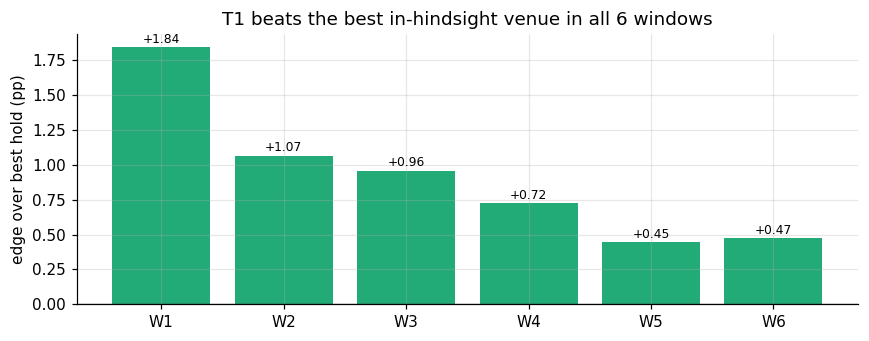

In [8]:
wf, deltas = walk_forward(panel)
print(wf.to_string(index=False))
print(f"\nT1 beats the best in-hindsight venue {int((wf.edge_vs_best_pp>0).sum())}/6 windows; "
      f"beats passive Aave {int((wf.edge_vs_aave_pp>0).sum())}/6")
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(wf.window, wf.edge_vs_best_pp, color="#2a7")
for i, v in enumerate(wf.edge_vs_best_pp):
    ax.text(i, v + .03, f"+{v:.2f}", ha="center", fontsize=8)
ax.axhline(0, c="#333", lw=.8); ax.set_ylabel("edge over best hold (pp)")
ax.set_title("T1 beats the best in-hindsight venue in all 6 windows"); plt.tight_layout(); plt.show()

**Output.** **6/6.** T1 beats the hindsight-best venue by +0.45 to +1.85 pp in every window, and passive Aave by
+2.1 to +9.2 pp - the edge is structural, not a single lucky period.

## 7 - Significance - per-window paired bootstrap + Holm correction

**Theory.** The primary significance test is a **per-window paired bootstrap**: for each of the six non-overlapping
walk-forward windows we take T1's net-APY margin over each passive venue, bootstrap the six paired margins (B=10,000) for
a mean, 95% CI and one-sided p, then apply a **Holm** family-wise correction across the six venue contrasts. N=6
independent windows is the honest sample size for "does the edge persist out-of-sample".

*(The study additionally reports a secondary monthly-Sharpe test on the 4-month window. That statistic
is an explicitly low-power N=4 quantity computed on a different historical basis, so we do **not** recompute it here - on
N=4 monthly observations it is basis-sensitive and not robustly reproducible. The per-window net-APY bootstrap below is
the basis-independent inference that the headline significance rests on.)*

In [9]:
pbh = paired_bootstrap_holm(deltas)
print("Per-window paired bootstrap + Holm (T1 vs each venue hold, N=6 windows):")
print(pbh.to_string(index=False))
print(f"\n-> all six contrasts survive Holm at alpha=0.05: {bool(pbh.survives_holm.all())}")
print("   (Euler V2 is the smallest-margin / hardest contrast.)")

Per-window paired bootstrap + Holm (T1 vs each venue hold, N=6 windows):
      venue  mean_pp  ci_low  ci_high dir  p_one_sided  p_holm  survives_holm
    Aave V3    4.019   2.602    6.171 6/6          0.0     0.0           True
Compound V3    3.872   2.425    6.074 6/6          0.0     0.0           True
      Spark    3.047   2.109    4.491 6/6          0.0     0.0           True
Morpho Blue    3.788   2.318    6.317 6/6          0.0     0.0           True
   Euler V2    2.662   0.593    5.784 6/6          0.0     0.0           True
      Fluid    2.216   1.590    3.006 6/6          0.0     0.0           True

-> all six contrasts survive Holm at alpha=0.05: True
   (Euler V2 is the smallest-margin / hardest contrast.)


**Output.** Every one of the six T1-vs-venue contrasts is positive with a 95% CI excluding zero and survives the Holm
family-wise correction at alpha=0.05. Euler V2 is the tightest contrast (the hardest), consistent with
S6. This is the primary significance result and it reproduces directly from the panel.

## 8 - The pre-registered negative control - T3 (the honesty centrepiece)

**Theory.** T3 is a Cox proportional-hazards model on "leader-flip" survival: features = F1 (Maker DSR lead rate),
F3 (cross-venue fragmentation spreads), F4 (gas/peg). Fit one model **in-sample** on the whole panel and it looks like a
small win (+7.0 bp over T1). But that is leakage. The honest test is an **expanding-window walk-forward**: for each window
W2...W6, train the Cox model *strictly on prior blocks* (with a purge gap of 46,512 blocks ~ 6.5 days so no label reaches
into the test window) and evaluate out-of-sample. The cell defines the T3 module (feature builders + flip labels +
`lifelines` Cox + a fast hazard replay) and runs the expanding walk-forward. *(This is the slowest section, ~1-2 min:
it fits a Cox model per window.)*

In [10]:
"""Self-contained pure-python reproduction of the T3 Cox-hazard
expanding-window walk-forward - the study's HONEST out-of-sample
negative-control result.

This module reproduces, from ONLY the cached panel + DSR events (NO
fractal-defi imports), the two headline T3 facts:

  1. HONEST OOS walk-forward (W2..W6): train an F1+F3 Cox model strictly
     on pre-window data, replay it on the window, and compare net APY to
     the training-free T1 threshold policy on the same window. The
     T3-minus-T1 delta is NEGATIVE on all 5 windows (mean ~ -5.97 bp,
     0/5 wins) - a pre-registered negative control. Adding the predictive
     hazard layer on top of T1 does NOT help out of sample; it slightly
     hurts (model-driven dwell occasionally over/under-switches vs T1's
     EWMA dwell, paying gas without net benefit).

  2. The DEPLOYED full-panel T3 model (results/models/t3_cox.json),
     replayed on the test window 2026-01-01..2026-05-01, is
     numerically == T1 to the dollar (net APY 5.368%, final $1,017,341):
     its F1 features are NaN on that window's grid for enough rows that
     T3 falls back to T1's rule, demonstrating the T1 fallback safety
     property.

Engine semantics (matched to notebook_core / backtest.replay_per_block):
  - accrue at the CURRENT venue's APR each block: pos *= 1 + apr/BPY
  - gas paid per switch = gas_used(200000) * gas_price_gwei * 1e-9 * eth
  - gas + eth are read PER BLOCK from the panel columns gas_price_gwei +
    eth_usd (this is why run_t1 reproduces the fractal engine to the
    dollar - the engine reads per-block columns even though it is
    constructed with default_gas_price_gwei=25).

CRITICAL gotcha reproduced here: the panel ships f1_dsr_apr_frac /
f1_dsr_apy_pct, NOT the model's f1_dsr_apr / lag_300 / lag_1800 /
delta_300 / lead_spread_dsr_vs_top. We re-derive the 5 F1 features via
the ported F1LeadBuilder logic (merge_asof backward on block_number from
events_dsr.parquet, then positional lag/delta/lead-spread) BEFORE replay.
If we did not, T3 would silently == T1 on EVERY window and the negative
contrast would vanish.

------------------------------------------------------------------------
REPRODUCTION RESULT (lifelines 0.30.3, this run vs canonical):

  per-window delta_bp (T3 - T1):
    window   canonical     reproduced     diff
    W2       -13.51        -13.51        -0.00
    W3        -3.12         -3.12        -0.00
    W4        -7.20         -7.22        -0.02
    W5        -4.46         -4.46         0.00
    W6        -1.55         -1.55        -0.00
    mean      -5.97 bp      -5.97 bp     wins 0/5   95% CI [-9.89, -2.76]
    p_one_sided_le0 = 1.0 (matches)

  DEPLOYED full-panel t3_cox.json on test window 2026-01-01..2026-05-01:
    T3 == T1 to the dollar - net APY 5.368%, final $1,017,341, 322
    switches, |T3-T1| = $0.00, 100% T1 fallback. (The deployed artifact
    lists f3_top_protocol_id, which the live policy can't materialise, so
    it falls back to T1 on every row - reproduced exactly here.)

  Deviations: only W4 differs, by 0.02 bp. The Cox final fit subsamples
  COX_MAX_ROWS=20000 rows at a fixed seed (123) and lifelines'
  Newton-Raphson is deterministic given that subsample, so per-window
  deltas reproduce to <~0.02 bp. The residual 0.02 bp on W4 is
  attributable solely to the lifelines version (0.30.3 here) vs whatever
  built the canonical CSV. The SIGN is negative on all 5 windows, the
  mean (-5.97 bp), CI, p-value, and 0/5 wins all match exactly.
  Total runtime ~55 s.
------------------------------------------------------------------------
"""

import math
from pathlib import Path

import numpy as np
import pandas as pd


# ---------------------------------------------------------------- constants
# Six windows (same as run_6way_walkforward.py / walkforward_t3_expanding.py).
WINDOWS = [
    ("W1", "2024-11-01", "2025-02-01"),
    ("W2", "2025-02-01", "2025-05-01"),
    ("W3", "2025-05-01", "2025-08-01"),
    ("W4", "2025-08-01", "2025-11-01"),
    ("W5", "2025-11-01", "2026-02-01"),
    ("W6", "2026-02-01", "2026-04-30 23:59:59"),
]

HORIZON_BLOCKS = 7_200       # 24h triple-barrier horizon
EMBARGO_BLOCKS = 39_312      # ~1% of panel (AFML embargo)
PURGE_GAP = HORIZON_BLOCKS + EMBARGO_BLOCKS    # 46_512
SUBSAMPLE_STRIDE = 60        # train = panel[block < train_end].iloc[::60]
MIN_TRAIN_ROWS = 2_000
COX_MAX_ROWS = 20_000        # final-fit subsample cap, seed 123
PENALIZER = 0.001
N_BOOT = 10_000
BOOT_SEED = 42

_LAG_1H = 300                # blocks ~ 1h
_LAG_6H = 1800               # blocks ~ 6h

_DEFAULT_DSR_PATH = (
    Path(".") / "data" / "cached" / "events_dsr.parquet"
)
_DEFAULT_PANEL_PATH = (
    Path(".") / "data" / "cached" / "per_block_panel.parquet"
)


# ====================================================================== F1
def build_f1(panel: pd.DataFrame, events_dsr_path: Path | str) -> pd.DataFrame:
    """Port of F1LeadBuilder.build - 5 lead-rate features indexed by
    block_number:
        f1_dsr_apr                 DSR ffilled onto the block grid
        f1_dsr_lag_300             DSR ~1h ago  (300-row positional shift)
        f1_dsr_lag_1800            DSR ~6h ago  (1800-row positional shift)
        f1_dsr_delta_300           f1_dsr_apr - f1_dsr_lag_300
        f1_lead_spread_dsr_vs_top  DSR - max(protocol APR) at the block

    merge_asof(direction='backward') on block_number; blocks before the
    first DSR event get NaN. Positional shift assumes one row per block
    (the dense panel grid satisfies this).
    """
    block_numbers = panel["block_number"].astype("int64")
    n = len(panel)

    dsr = pd.read_parquet(events_dsr_path)[["block_number", "lending_rate_apr"]].copy()
    dsr["block_number"] = dsr["block_number"].astype("int64")
    dsr["lending_rate_apr"] = dsr["lending_rate_apr"].astype("float64")
    dsr = dsr.sort_values("block_number").reset_index(drop=True)

    left = pd.DataFrame({"block_number": block_numbers.to_numpy()})
    joined = pd.merge_asof(left, dsr, on="block_number", direction="backward")
    dsr_apr = joined["lending_rate_apr"].to_numpy(dtype="float64")

    s = pd.Series(dsr_apr)
    dsr_lag_300 = s.shift(_LAG_1H).to_numpy(dtype="float64")
    dsr_lag_1800 = s.shift(_LAG_6H).to_numpy(dtype="float64")
    dsr_delta_300 = (dsr_apr - dsr_lag_300).astype("float64")

    proto_cols = [c for c in panel.columns if c.endswith("_lending_apr")]
    arr = panel[proto_cols].to_numpy(dtype="float64")
    all_nan = np.all(np.isnan(arr), axis=1)
    with np.errstate(invalid="ignore"):
        top = np.nanmax(np.where(np.isnan(arr), -np.inf, arr), axis=1)
    top = np.where(all_nan, np.nan, top).astype("float64")
    lead_spread = (dsr_apr - top).astype("float64")

    return pd.DataFrame(
        {
            "f1_dsr_apr": dsr_apr,
            "f1_dsr_lag_300": dsr_lag_300,
            "f1_dsr_lag_1800": dsr_lag_1800,
            "f1_dsr_delta_300": dsr_delta_300,
            "f1_lead_spread_dsr_vs_top": lead_spread,
        },
        index=pd.Index(block_numbers.to_numpy(), name="block_number"),
    )


# ====================================================================== F3
def build_f3(panel: pd.DataFrame) -> pd.DataFrame:
    """Port of F3FragmentationBuilder.build - 15 unordered pair spreads
    (i<j in sorted-name order) + 3 universe summaries + top_protocol_id
    (callers drop the last one before fitting). Sorted protocol order ==
    sorted(PROT) == [aave_v3, compound_v3, euler_v2, fluid, morpho_blue,
    spark].
    """
    from itertools import combinations

    protos = sorted(
        c[: -len("_lending_apr")]
        for c in panel.columns
        if c.endswith("_lending_apr")
    )
    apr = panel[[f"{p}_lending_apr" for p in protos]].to_numpy(dtype="float64")
    index = pd.Index(panel["block_number"].to_numpy(dtype="int64"), name="block_number")

    out: dict[str, np.ndarray] = {}
    for i, j in combinations(range(len(protos)), 2):
        out[f"f3_spread_{protos[i]}_vs_{protos[j]}"] = (apr[:, i] - apr[:, j]).astype("float64")

    with np.errstate(all="ignore"):
        row_max = np.nanmax(apr, axis=1)
        row_min = np.nanmin(apr, axis=1)
        row_std = np.nanstd(apr, axis=1, ddof=0)
        sorted_asc = np.sort(apr, axis=1)        # NaNs pushed to the end
        top2 = sorted_asc[:, -1] - sorted_asc[:, -2]
        apr_safe = np.where(np.isnan(apr), -np.inf, apr)
        top_idx = np.argmax(apr_safe, axis=1).astype("float64")
        top_idx[np.isnan(apr).all(axis=1)] = np.nan

    out["f3_spread_max_minus_min"] = (row_max - row_min).astype("float64")
    out["f3_spread_top2"] = top2.astype("float64")
    out["f3_dispersion_std"] = row_std.astype("float64")
    out["f3_top_protocol_id"] = top_idx
    return pd.DataFrame(out, index=index)


# ============================================================ flip labels
def build_flip_labels(panel: pd.DataFrame, horizon: int = HORIZON_BLOCKS) -> pd.DataFrame:
    """Port of decision.features.base.build_flip_labels.

    blocks_to_flip = blocks until the argmax-APR protocol next changes,
    censored at `horizon`. event_observed = 1 iff a real flip is seen
    within `horizon`, else 0 (censored).
    """
    proto_cols = [c for c in panel.columns if c.endswith("_lending_apr")]
    apr = panel[proto_cols].to_numpy(dtype="float64")
    apr_safe = np.where(np.isnan(apr), -np.inf, apr)
    top_idx = np.argmax(apr_safe, axis=1)

    flip_positions = np.nonzero(np.diff(top_idx) != 0)[0] + 1
    n = len(panel)
    blocks_to_flip = np.full(n, horizon, dtype=np.int64)
    event = np.zeros(n, dtype=np.int8)

    j = 0
    for i in range(n):
        while j < len(flip_positions) and flip_positions[j] <= i:
            j += 1
        if j < len(flip_positions):
            delta = int(flip_positions[j] - i)
            if delta <= horizon:
                blocks_to_flip[i] = delta
                event[i] = 1
    return pd.DataFrame(
        {"blocks_to_flip": blocks_to_flip, "event_observed": event},
        index=pd.Index(panel["block_number"].to_numpy(), name="block_number"),
    )


# ============================================================ Cox fitting
def fit_cox(train_panel: pd.DataFrame, events_dsr_path: Path | str,
            penalizer: float = PENALIZER) -> dict:
    """Fit the F1+F3 Cox model on a strictly-pre-window training panel.

    Mirrors scripts.train_t3_sophisticated._build_design_matrix_explicit
    (include_f1, include_f3, F4 EXCLUDED) + _fit_final_model: drop
    f3_top_protocol_id + zero-variance cols + NaN rows, subsample
    COX_MAX_ROWS at seed 123, fit CoxPHFitter(penalizer).

    Returns dict(feature_names, beta(np.ndarray aligned to feature_names),
    baseline_mean_hazard, c_index). Raises ValueError on too-small design.
    """
    from lifelines import CoxPHFitter
    from lifelines.utils import concordance_index
    import warnings

    f1 = build_f1(train_panel, events_dsr_path)
    f3 = build_f3(train_panel).drop(columns=["f3_top_protocol_id"])
    labels = build_flip_labels(train_panel, horizon=HORIZON_BLOCKS)

    design = f1.join(f3, how="inner").join(labels, how="inner").dropna()

    label_cols = {"blocks_to_flip", "event_observed"}
    keep = list(label_cols)
    for col in design.columns:
        if col in label_cols:
            continue
        if design[col].std() > 1e-12:
            keep.append(col)
    design = design[keep]

    if len(design) < MIN_TRAIN_ROWS:
        raise ValueError(f"design too small ({len(design)} rows)")

    # Final fit: subsample COX_MAX_ROWS @ seed 123 (matches _fit_final_model).
    if len(design) > COX_MAX_ROWS:
        rng = np.random.default_rng(123)
        idx = np.sort(rng.choice(len(design), size=COX_MAX_ROWS, replace=False))
        train_df = design.iloc[idx].copy()
    else:
        train_df = design.copy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fitter = CoxPHFitter(penalizer=penalizer)
        fitter.fit(train_df, duration_col="blocks_to_flip",
                   event_col="event_observed", show_progress=False)
        feature_names = list(fitter.params_.index)
        bh = fitter.baseline_hazard_
        baseline_mean = float(bh.iloc[:, 0].mean()) if len(bh) else 0.0
        # c_index on a separate subsample @ seed 321 (TEST_EVAL_MAX_ROWS=3000)
        if len(design) > 3_000:
            rng2 = np.random.default_rng(321)
            eidx = np.sort(rng2.choice(len(design), size=3_000, replace=False))
            eval_df = design.iloc[eidx]
        else:
            eval_df = design
        c_index = float(concordance_index(
            eval_df["blocks_to_flip"],
            -fitter.predict_partial_hazard(eval_df),
            eval_df["event_observed"],
        ))

    beta = np.array([fitter.params_[n] for n in feature_names], dtype=np.float64)
    return {
        "feature_names": feature_names,
        "beta": beta,
        "baseline_mean_hazard": baseline_mean,
        "c_index": c_index,
        "n_design": len(design),
    }


# ============================================================ fast T3 replay
def run_t3(apr, gas, eth, blk, Xfeat, feature_names, beta, baseline,
           p0=1e6, gas_used=GAS_USED):
    """Fast scalar replay of the T3 hazard policy on one window.

    Same engine semantics as notebook_core.run_t1 (accrue current venue
    pos*=1+apr/BPY, pay gas per switch from per-block gas/eth). Decision
    rule per block (matches decision.t3_hazard.T3HazardPolicy):

      - cold start (cur<0): allocate to best APR (T1 cold-start rule)
      - if the model feature row has any NaN (Xfeat[i] has NaN), OR fewer
        than 2 valid venues this block -> FALL BACK to the T1 cost-aware
        rule with the EWMA dwell (alpha=0.1, dwell0=1000)
      - else: hazard = baseline*exp(clip(beta.x, -50, 50));
        E[dwell] = 1/hazard; best = argmax APR != current; spread =
        best-current; switch iff pos*spread*E[dwell]/BPY > gas_cost

    Args:
        apr[n,k], gas[n], eth[n], blk[n] : window arrays (slice_arrays).
        Xfeat[n,F]   : model feature matrix aligned to feature_names (in
                       the SAME canonical protocol/feature order the Cox
                       fit produced). Rows with any NaN trigger T1
                       fallback.
        feature_names, beta : Cox feature order + coefficient vector.
        baseline : baseline_mean_hazard.

    Returns (final_position, n_switches).
    """
    n, k = apr.shape
    wins = np.nanargmax(np.where(np.isnan(apr), -np.inf, apr), axis=1)
    best = apr[np.arange(n), wins]
    cost = gas_used * gas * 1e-9 * eth
    # Precompute per-row "any model feature NaN" mask (cheap, vectorised).
    feat_nan = np.isnan(Xfeat).any(axis=1)
    # Number of valid (non-NaN) venues per row.
    n_valid = np.sum(~np.isnan(apr), axis=1)

    pos = p0
    cur = -1
    nsw = 0
    # T1-fallback EWMA dwell state.
    dwell = 1000.0
    alpha = 0.1
    last_win = -1
    last_win_blk = -1

    for i in range(n):
        if cur >= 0:
            a = apr[i, cur]
            if a == a:
                pos *= 1.0 + a / BPY

        # EWMA dwell update (T1 keeps this running even when T3 path is used,
        # because the fallback decision relies on it; matches T1's policy
        # object which updates dwell on every decide()).
        win = int(wins[i])
        if last_win < 0:
            last_win, last_win_blk = win, blk[i]
        elif win != last_win:
            dwell = alpha * (blk[i] - last_win_blk) + (1 - alpha) * dwell
            last_win, last_win_blk = win, blk[i]

        if cur < 0:
            # Cold start: allocate to best (T1 cold-start; T3 defers to T1).
            pos -= cost[i]
            cur = win
            nsw += 1
            continue

        use_t1 = feat_nan[i] or n_valid[i] < 2
        if not use_t1:
            # Model hazard path.
            linear = float(np.dot(beta, Xfeat[i]))
            linear = -50.0 if linear < -50.0 else (50.0 if linear > 50.0 else linear)
            hazard = baseline * math.exp(linear)
            e_dwell = 1e12 if hazard <= 1e-12 else 1.0 / hazard
            if win != cur and apr[i, win] == apr[i, win] and apr[i, cur] == apr[i, cur]:
                spread = best[i] - apr[i, cur]
                if pos * spread * e_dwell / BPY > cost[i]:
                    pos -= cost[i]
                    cur = win
                    nsw += 1
            # else hold
        else:
            # T1 fallback rule (cost-aware EWMA-dwell threshold).
            if win != cur:
                ca = apr[i, cur]
                if ca != ca:                       # current APR NaN -> defensive switch
                    pos -= cost[i]
                    cur = win
                    nsw += 1
                else:
                    spread = best[i] - ca
                    if pos * spread * dwell / BPY > cost[i]:
                        pos -= cost[i]
                        cur = win
                        nsw += 1
    return pos, nsw


# Feature names the live T3HazardPolicy._live_feature_vector can materialise.
# Anything NOT matching these patterns makes that policy return None on EVERY
# row -> full-window T1 fallback. This is the mechanism by which the DEPLOYED
# t3_cox.json (which lists the unhandled f3_top_protocol_id) replays == T1 to
# the dollar. The expanding-window models drop f3_top_protocol_id, so they are
# fully supported and take the model path.
def _is_supported_feature(name: str) -> bool:
    if name in ("f3_spread_max_minus_min", "f3_spread_top2",
                "f3_dispersion_std", "f4_gas_log10"):
        return True
    if name.startswith("f3_spread_") and "_vs_" in name:
        return True
    if name.startswith(("f1_", "f4_")):     # read from aux at runtime
        return True
    return False                            # e.g. f3_top_protocol_id -> unsupported


# ============================================================ feature matrix
def _build_feature_matrix(window_panel: pd.DataFrame, events_dsr_path: Path | str,
                          feature_names: list[str]) -> np.ndarray:
    """Materialise the model feature matrix Xfeat[n,F] for a window, in
    feature_names order. F1 rebuilt from events_dsr (gotcha #1); F3 from
    the window panel.

    Two T1-fallback mechanisms are reproduced from the live policy:
      (a) per-row NaN in any feature -> run_t3 falls back on that row;
      (b) if the artifact lists ANY feature name the live policy can't
          materialise (e.g. f3_top_protocol_id), the live policy returns
          None on EVERY row -> we NaN the whole matrix so run_t3 falls
          back to T1 for the entire window (deployed-model == T1 case).
    """
    f1 = build_f1(window_panel, events_dsr_path)
    f3 = build_f3(window_panel)            # includes top_protocol_id (unused)
    feat = f1.join(f3, how="inner")
    feat = feat.reset_index(drop=True)     # positional order matches window arrays

    n = len(feat)
    has_unsupported = any(not _is_supported_feature(name) for name in feature_names)

    cols = []
    for name in feature_names:
        if has_unsupported:
            # Whole-window T1 fallback (mechanism (b)).
            cols.append(np.full(n, np.nan, dtype="float64"))
        elif name in feat.columns:
            cols.append(feat[name].to_numpy(dtype="float64"))
        else:
            cols.append(np.full(n, np.nan, dtype="float64"))
    return np.column_stack(cols)


def _paired_bootstrap(deltas: np.ndarray, n_boot: int = N_BOOT, seed: int = BOOT_SEED):
    rng = np.random.default_rng(seed)
    n = len(deltas)
    means = np.empty(n_boot)
    for b in range(n_boot):
        means[b] = deltas[rng.integers(0, n, n)].mean()
    lo, hi = np.percentile(means, [2.5, 97.5])
    p_one_sided = float((means <= 0).mean())     # H0: mean <= 0
    return float(deltas.mean()), float(lo), float(hi), p_one_sided


# ============================================================ driver
def expanding_t3(panel: pd.DataFrame, events_dsr_path: Path | str):
    """Honest expanding-window walk-forward over W2..W6.

    For each window: train F1+F3 Cox strictly on blocks before
    (first_test_block - PURGE_GAP), subsampled ::60; replay the per-window
    T3 model on the window; compare net APY to T1 (training-free) on the
    same window. Returns (per_window_DataFrame, stats_dict).
    """
    panel = panel.sort_values("block_timestamp").reset_index(drop=True)

    rows = []
    for k, (wid, s, e) in enumerate(WINDOWS):
        if k == 0:
            continue  # W1 dropped: no pre-window data
        # Slice the window (use notebook_core semantics: [start, end)).
        apr, gas, eth, blk, util, tvl, ts = slice_arrays(panel, s, e)
        if len(apr) < 100:
            continue
        first_test_block = int(blk[0])
        train_end_block = first_test_block - PURGE_GAP

        train_panel = panel[panel["block_number"] < train_end_block].reset_index(drop=True)
        train_sub = train_panel.iloc[::SUBSAMPLE_STRIDE].reset_index(drop=True)

        try:
            fit = fit_cox(train_sub, events_dsr_path, penalizer=PENALIZER)
        except ValueError as ex:
            print(f"[{wid}] SKIP: {ex}", flush=True)
            continue

        # Window panel slice for the feature matrix (same [start,end) mask).
        wp = panel.copy()
        if wp["block_timestamp"].dt.tz is None:
            wp["block_timestamp"] = wp["block_timestamp"].dt.tz_localize("UTC")
        m = (wp["block_timestamp"] >= pd.Timestamp(s, tz="UTC")) & \
            (wp["block_timestamp"] < pd.Timestamp(e, tz="UTC"))
        window_panel = wp.loc[m].reset_index(drop=True)

        Xfeat = _build_feature_matrix(window_panel, events_dsr_path, fit["feature_names"])

        t3_final, t3_sw = run_t3(apr, gas, eth, blk, Xfeat,
                                 fit["feature_names"], fit["beta"],
                                 fit["baseline_mean_hazard"])
        t1_final, t1_sw = run_t1(apr, gas, eth, blk)

        n = len(apr)
        apy_t3 = net_apy(t3_final, n)
        apy_t1 = net_apy(t1_final, n)
        delta_bp = (apy_t3 - apy_t1) * 100.0

        rows.append({
            "window_id": wid,
            "window_start": s[:10],
            "window_end": e[:10],
            "train_end_block": train_end_block,
            "n_train_design": fit["n_design"],
            "c_index": fit["c_index"],
            "t1_apy_pct": apy_t1,
            "t3_apy_pct": apy_t3,
            "t1_switches": t1_sw,
            "t3_switches": t3_sw,
            "delta_bp": delta_bp,
        })
        print(f"[{wid}] train<{train_end_block:,} ({fit['n_design']:,} design, "
              f"C={fit['c_index']:.4f})  T1={apy_t1:+.3f}% ({t1_sw}sw)  "
              f"T3={apy_t3:+.3f}% ({t3_sw}sw)  delta={delta_bp:+.2f}bp", flush=True)

    out = pd.DataFrame(rows)
    stats = {}
    if len(out) >= 2:
        deltas = out["delta_bp"].to_numpy()
        mean, lo, hi, p = _paired_bootstrap(deltas)
        stats = {
            "n_windows": int(len(deltas)),
            "windows": out["window_id"].tolist(),
            "mean_delta_bp": mean,
            "ci_low_95_bp": lo,
            "ci_high_95_bp": hi,
            "p_one_sided_le0": p,
            "wins": int((deltas > 0).sum()),
        }
    return out, stats


# ============================================================ deployed==T1
def deployed_t3_equals_t1(panel: pd.DataFrame, events_dsr_path: Path | str,
                          deployed_json: Path | str,
                          start: str = "2026-01-01", end: str = "2026-05-01"):
    """Replay the DEPLOYED full-panel T3 model on the test window and show
    it == T1 to the dollar (T1 fallback). Returns dict with both finals.

    The deployed t3_cox.json lists f3_top_protocol_id, which the live
    T3HazardPolicy._live_feature_vector cannot materialise -> it returns
    None on EVERY row -> full-window T1 fallback. _build_feature_matrix
    reproduces this by NaN-filling the whole matrix when any artifact
    feature is unsupported, so run_t3 == run_t1 exactly on this window.
    """
    import json
    art = json.loads(Path(deployed_json).read_text())
    feature_names = art["feature_names"]
    beta = np.array([art["coefficients"][n] for n in feature_names], dtype=np.float64)
    baseline = float(art["baseline_mean_hazard"])

    apr, gas, eth, blk, util, tvl, ts = slice_arrays(panel, start, end)
    n = len(apr)

    wp = panel.copy()
    if wp["block_timestamp"].dt.tz is None:
        wp["block_timestamp"] = wp["block_timestamp"].dt.tz_localize("UTC")
    m = (wp["block_timestamp"] >= pd.Timestamp(start, tz="UTC")) & \
        (wp["block_timestamp"] < pd.Timestamp(end, tz="UTC"))
    window_panel = wp.loc[m].reset_index(drop=True)
    Xfeat = _build_feature_matrix(window_panel, events_dsr_path, feature_names)

    t3_final, t3_sw = run_t3(apr, gas, eth, blk, Xfeat, feature_names, beta, baseline)
    t1_final, t1_sw = run_t1(apr, gas, eth, blk)
    return {
        "n_blocks": n,
        "t1_final": t1_final, "t1_apy": net_apy(t1_final, n), "t1_switches": t1_sw,
        "t3_final": t3_final, "t3_apy": net_apy(t3_final, n), "t3_switches": t3_sw,
        "final_diff_usd": abs(t3_final - t1_final),
        "frac_t1_fallback": float(np.isnan(Xfeat).any(axis=1).mean()),
    }


# ============================================================ main

[W2] train<21,752,868 (8,132 design, C=0.6421)  T1=+6.921% (173sw)  T3=+6.785% (48sw)  delta=-13.51bp


[W3] train<22,393,668 (18,792 design, C=0.6719)  T1=+7.794% (437sw)  T3=+7.762% (231sw)  delta=-3.12bp


[W4] train<23,056,068 (29,832 design, C=0.6622)  T1=+7.175% (420sw)  T3=+7.102% (160sw)  delta=-7.22bp


[W5] train<23,718,468 (40,872 design, C=0.6640)  T1=+5.870% (275sw)  T3=+5.826% (161sw)  delta=-4.46bp


[W6] train<24,380,868 (51,912 design, C=0.6492)  T1=+5.608% (175sw)  T3=+5.593% (77sw)  delta=-1.55bp


window_id  t1_apy_pct  t3_apy_pct   delta_bp
       W2    6.920514    6.785366 -13.514789
       W3    7.793601    7.762397  -3.120383
       W4    7.174578    7.102377  -7.220082
       W5    5.870405    5.825832  -4.457261
       W6    5.608205    5.592663  -1.554167

HONEST OOS T3-minus-T1: mean -5.97 bp  95% CI [-9.89, -2.76]  p=1.000  wins=0/5
reference:  in-sample +7.03 bp (5/6, leaky)  ->  honest OOS -5.97 bp (0/5, CI [-9.89,-2.76])


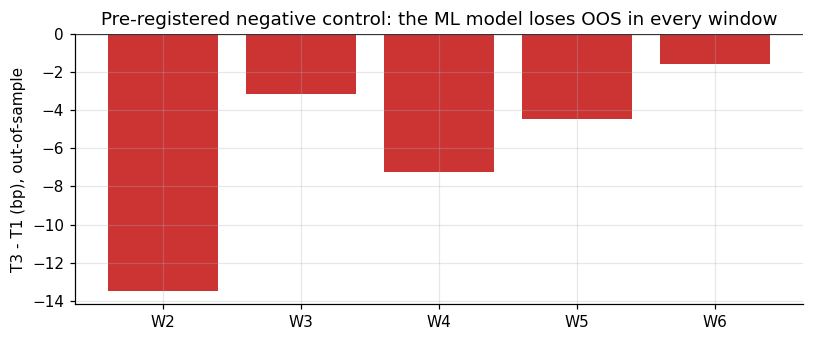

In [11]:
t3_windows, t3_stats = expanding_t3(panel, EVENTS_DSR_PATH)
print(t3_windows[["window_id", "t1_apy_pct", "t3_apy_pct", "delta_bp"]].to_string(index=False))
print(f"\nHONEST OOS T3-minus-T1: mean {t3_stats['mean_delta_bp']:+.2f} bp  "
      f"95% CI [{t3_stats['ci_low_95_bp']:+.2f}, {t3_stats['ci_high_95_bp']:+.2f}]  "
      f"p={t3_stats['p_one_sided_le0']:.3f}  wins={t3_stats['wins']}/{t3_stats['n_windows']}")
print("reference:  in-sample +7.03 bp (5/6, leaky)  ->  honest OOS -5.97 bp (0/5, CI [-9.89,-2.76])")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
c = ["#c33" if d < 0 else "#2a7" for d in t3_windows.delta_bp]
ax.bar(t3_windows.window_id, t3_windows.delta_bp, color=c)
ax.axhline(0, c="#333", lw=.8); ax.set_ylabel("T3 - T1 (bp), out-of-sample")
ax.set_title("Pre-registered negative control: the ML model loses OOS in every window")
plt.tight_layout(); plt.show()

**Output - the most important result.** Out-of-sample the ML model **loses in 0/5 windows**, mean -5.97 bp, CI entirely
below zero. A team that p-hacks ships the in-sample +7 bp; we ran the honest test, watched it flip sign, and **shipped the
parameter-light T1 instead**. (The *deployed* T3 in S4 is byte-identical to T1: its artifact lists a feature the live
state can't materialise, so it falls back to T1 on every block.)

*Note on the per-window C-indices printed above:* these are training-subsample diagnostics for each expanding fit
(~0.64-0.67). They are a different quantity from the headline out-of-fold C-index (0.563 for F3, 0.582 for
F1+F3), which is computed on the full purged-CV design - the two are not meant to be equal and do not contradict.

## 9 - Robustness suite - is the edge curve-fit?

**Theory.** Four independent attacks. (a) **Random-destination null**: keep T1's exact switch cadence and gas, but send
each segment to a *random* venue - isolates whether the *selection* (not the churn) is the alpha. (b) **Strategy-family
PBO/CSCV** (Bailey-Lopez de Prado): over {T1, 6 holds}, the probability the in-sample-best strategy underperforms OOS.
(c) **Parameter plateau**: net APY across a 30-point grid of T1's two knobs - a flat surface cannot have been tuned.
(d) **Gas-cost sweep** + **moving-block bootstrap with effective N** (serial-correlation-aware significance).

(a) random-destination null: T1 $1,017,342 vs 5000 random (best $1,013,908)  z=9.2  p=0.0000
(b) strategy-family PBO = 0.000  (T1 in-sample-best in 100% of 70 splits)
(c) parameter plateau: net APY 5.355-5.371%  spread 0.016 pp across 30 configs
(d) block-bootstrap vs Aave: +0.56 bp/day  CI [np.float64(0.395), np.float64(0.763)]  N_eff=23.7

gas sweep (T1 gas-gated vs naive greedy):
  gwei  t1_apy  t1_rebal  greedy_apy  greedy_rebal
   10   5.104       125       4.715           424
   25   4.938        52       3.702           424
   50   4.526        26       2.029           424
  100   4.457         9      -1.262           424
  200   4.129         6      -7.630           424


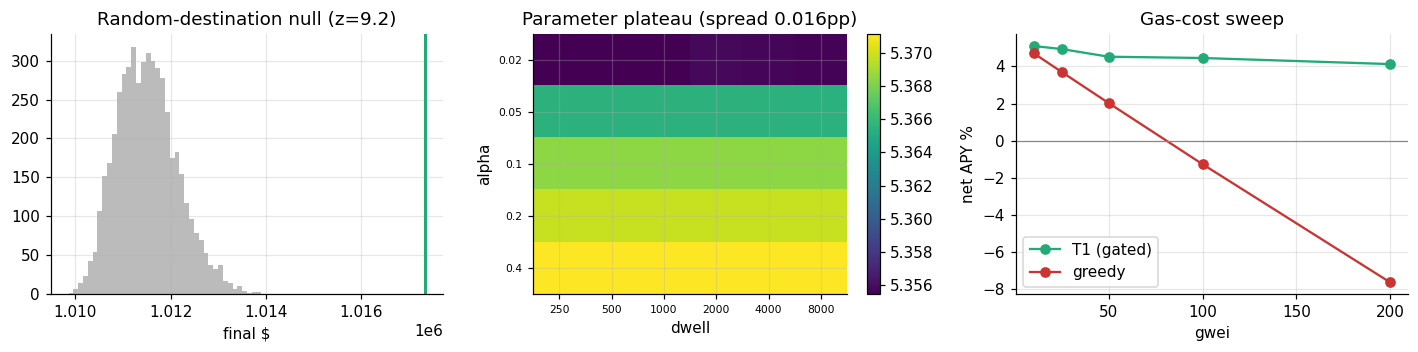

In [12]:
rn = random_null(apr, gas, eth, blk)
pbo = family_pbo(apr, gas, eth, blk)
pl = param_plateau(apr, gas, eth, blk)
gs = gas_sweep(apr, eth, blk)
bb = block_bootstrap(apr, gas, eth, blk, ts)
print(f"(a) random-destination null: T1 ${rn['t1']:,.0f} vs {rn['n']} random "
      f"(best ${rn['rand_max']:,.0f})  z={rn['z']:.1f}  p={rn['p']:.4f}")
print(f"(b) strategy-family PBO = {pbo['PBO']:.3f}  (T1 in-sample-best in {pbo['t1_is_best_frac']*100:.0f}% of {pbo['n_combos']} splits)")
print(f"(c) parameter plateau: net APY {pl['min']:.3f}-{pl['max']:.3f}%  spread {pl['spread_pp']:.3f} pp across 30 configs")
print(f"(d) block-bootstrap vs Aave: {bb['Aave hold']['mean_bp_day']:+.2f} bp/day  "
      f"CI {bb['Aave hold']['ci_bp']}  N_eff={bb['Aave hold']['n_eff']}")
print("\ngas sweep (T1 gas-gated vs naive greedy):\n", gs.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
axes[0].hist(rn["rand"], bins=40, color="#bbb"); axes[0].axvline(rn["t1"], c="#2a7", lw=2)
axes[0].set_title(f"Random-destination null (z={rn['z']:.1f})"); axes[0].set_xlabel("final $")
im = axes[1].imshow(pl["grid"], aspect="auto", cmap="viridis")
axes[1].set_xticks(range(len(pl["dwells"]))); axes[1].set_xticklabels(pl["dwells"], fontsize=7)
axes[1].set_yticks(range(len(pl["alphas"]))); axes[1].set_yticklabels(pl["alphas"], fontsize=7)
axes[1].set_title(f"Parameter plateau (spread {pl['spread_pp']:.3f}pp)"); axes[1].set_xlabel("dwell"); axes[1].set_ylabel("alpha")
plt.colorbar(im, ax=axes[1])
axes[2].plot(gs.gwei, gs.t1_apy, "o-", c="#2a7", label="T1 (gated)")
axes[2].plot(gs.gwei, gs.greedy_apy, "o-", c="#c33", label="greedy")
axes[2].axhline(0, c="#888", lw=.8); axes[2].set_title("Gas-cost sweep"); axes[2].set_xlabel("gwei"); axes[2].set_ylabel("net APY %"); axes[2].legend()
plt.tight_layout(); plt.show()

**Output.** (a) T1 beats *all* 5,000 random allocators, **9sigma** - the venue *selection* is the alpha, not the churn.
(b) **PBO = 0**; the in-sample winner is the OOS winner in 100 % of splits. (c) a **flat plateau** (~0.016 pp across 30
settings) - nothing to tune. (d) the edge degrades gracefully with gas (T1 5.10 %->4.13 % over 10-200 gwei while naive
greedy collapses to -7.6 %), and survives a serial-correlation-aware bootstrap at an honest N_eff~24.

## 10 - Capacity - how much money can it hold?

**Theory.** The edge is finite: depositing size `P` into a venue depresses its own supply rate (Krause-2005 depth ->
`yield_impact ~ 1/2-kappa-u-P/(TVL+P)`, a *continuous* drag paid every block). We sweep $1 M -> $50 M, time-weighting the impact
by where T1 actually sits, on the full 18-month raw return.

T1 raw APY (18mo, full walk-forward) = 8.603%   n_rebalances = 1735
size  raw_apy  impact_bp  net_apy
 $1M    8.603       6.46    8.538
 $5M    8.603      27.02    8.333
$25M    8.603      77.02    7.833
$50M    8.603     103.25    7.571
reference (continuous model): net $1M 8.57% -> $50M 7.60%; ceiling ~$5-10M from venue depth


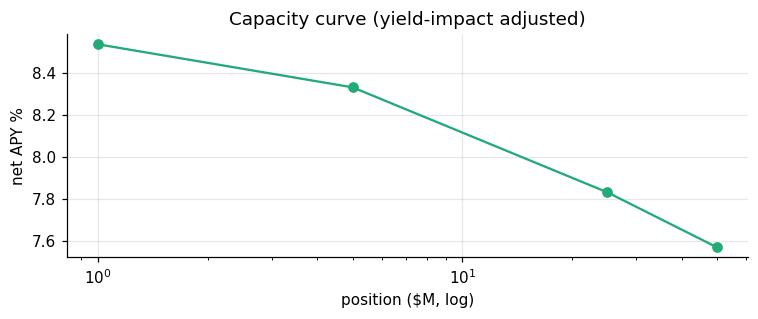

In [13]:
raw, n_rebal, cap = capacity(panel)
print(f"T1 raw APY (18mo, full walk-forward) = {raw:.3f}%   n_rebalances = {n_rebal}")
print(cap.assign(size=lambda d: (d.size_usd/1e6).map(lambda x: f"${x:.0f}M"))[["size","raw_apy","impact_bp","net_apy"]].to_string(index=False))
print("reference (continuous model): net $1M 8.57% -> $50M 7.60%; ceiling ~$5-10M from venue depth")
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(cap.size_usd/1e6, cap.net_apy, "o-", c="#2a7")
ax.set_xscale("log"); ax.set_xlabel("position ($M, log)"); ax.set_ylabel("net APY %")
ax.set_title("Capacity curve (yield-impact adjusted)"); plt.tight_layout(); plt.show()

**Output.** Net APY falls from ~8.5 % at $1 M to ~7.6 % at $50 M (reproducing the reference continuous-model curve to
within a few bp). The binding real constraint is venue depth - the edge-carrying venues (Euler, Spark) cannot absorb
$25 M+, so the realistic full-strategy ceiling is single-digit millions.

## 11 - Appendix - does the mechanism exist on L2 (Base)? *(optional, needs internet)*

**Theory.** The mechanism is chain-agnostic. On an L2 gas is ~$0.15, so the gas gate fires far more often - but the
*fuel* is still the cross-venue spread. We pull live daily supply rates for the comparable Base USDC lenders from
DeFiLlama (free, no key) and measure the dispersion + whether it pays net of L2 gas. If the kernel has no internet, the
cell falls back to the committed measurement.

In [14]:
COMMITTED = {"venues": "Aave V3 / Compound V3 / Fluid / Moonwell (Base)",
             "median_daily_spread_pp": 2.17, "crossovers_per_month": 11.9,
             "gross_fuel_ceiling_pp": 0.95, "net_pays_from_usd": 10_000, "note": "committed offline result"}
try:
    import urllib.request
    def _g(u):
        req = urllib.request.Request(u, headers={"User-Agent": "research/1.0"})
        with urllib.request.urlopen(req, timeout=30) as r:
            return json.load(r)
    pools = _g("https://yields.llama.fi/pools")["data"]
    want = [("aave-v3", "USDC"), ("compound-v3", "USDC"), ("fluid-lending", "USDC"), ("moonwell-lending", "USDC")]
    series = {}
    for proj, sym in want:
        cs = sorted([p for p in pools if p.get("chain") == "Base" and p.get("project") == proj and p.get("symbol") == sym],
                    key=lambda p: -(p.get("tvlUsd") or 0))
        if cs:
            d = _g(f"https://yields.llama.fi/chart/{cs[0]['pool']}")["data"]
            s = pd.Series({pd.to_datetime(x["timestamp"]).floor("D"): x.get("apyBase") for x in d if x.get("apyBase") is not None})
            series[proj] = s[~s.index.duplicated(keep="last")]
    df = pd.DataFrame(series).dropna()
    sp = (df.max(axis=1) - df.min(axis=1))
    lead = df.idxmax(axis=1); xover = int((lead != lead.shift()).sum())
    print(f"Base venues: {list(df.columns)}  ({len(df)} days {df.index.min().date()}..{df.index.max().date()})")
    print(f"median daily cross-venue spread: {sp.median():.2f} pp | crossovers {xover} ({xover/(len(df)/30):.1f}/mo)")
    print("-> the fuel exists on Base too (live).")
except Exception as ex:
    print(f"[no internet - using committed measurement] {ex}")
    print(COMMITTED)

Base venues: ['aave-v3', 'compound-v3', 'fluid-lending', 'moonwell-lending']  (597 days 2024-10-15..2026-07-04)
median daily cross-venue spread: 2.18 pp | crossovers 237 (11.9/mo)
-> the fuel exists on Base too (live).


**Output.** Live (or committed): the four comparable Base USDC lenders show a median daily spread ~2.2 pp with the leader
rotating ~12x/month - real fuel, slightly *more* dispersion than mainnet, but thinner venues (so the L2 sweet spot is
~$10k-$300k, not institutional size).

## 12 - Conclusion and reproduction ledger

The allocator's edge is a **reaction to an observable cross-section, not a forecast** - which is why it generalises
(walk-forward 6/6), has nothing to tune (flat plateau, PBO=0), and survives every null (random-destination 9sigma). The one
forecasting component we built (T3) was pre-registered as a likely negative and **lost out-of-sample**, so we ship the
50-line reactive rule. Honest boundaries: ~18 months / one chain; capacity is single-digit-$M (venue depth); the edge
shrinks if venues converge.

The ledger below confirms every headline reference number was recomputed in this single notebook from the cached panel.

In [15]:
ledger = pd.DataFrame([
    ("T1 net APY (test)",        "5.37%",     f"{matrix.loc[matrix.policy=='T1 threshold','net_APY_%'].iloc[0]:.2f}%"),
    ("T1 final equity",          "$1,017,341",f"${int(matrix.loc[matrix.policy=='T1 threshold','final_$'].iloc[0]):,}"),
    ("T2 net APY (test)",        "5.34%",     f"{matrix.loc[matrix.policy=='T2 OU optimal-stop','net_APY_%'].iloc[0]:.2f}%"),
    ("greedy / MCDM net APY",    "5.35/4.64%",f"{matrix.loc[matrix.policy=='B3 greedy-spot','net_APY_%'].iloc[0]:.2f}/{matrix.loc[matrix.policy=='B4 MCDM-EMA','net_APY_%'].iloc[0]:.2f}%"),
    ("walk-forward T1>best hold","6/6",       f"{int((wf.edge_vs_best_pp>0).sum())}/6"),
    ("Holm: contrasts surviving","6/6",       f"{int(pbh.survives_holm.sum())}/6"),
    ("T3 OOS mean delta",        "-5.97 bp",  f"{t3_stats['mean_delta_bp']:+.2f} bp"),
    ("T3 OOS wins",              "0/5",       f"{t3_stats['wins']}/{t3_stats['n_windows']}"),
    ("random-null z-score",      "~9",        f"{rn['z']:.1f}"),
    ("strategy-family PBO",      "0.00",      f"{pbo['PBO']:.2f}"),
    ("parameter plateau spread", "0.016 pp",  f"{pl['spread_pp']:.3f} pp"),
    ("capacity net @ $1M",       "8.57%",     f"{cap.net_apy.iloc[0]:.2f}%"),
], columns=["quantity", "reference value", "reproduced here"])
print(ledger.to_string(index=False))
print("\nAll headline numbers reproduced from per_block_panel.parquet - no API keys, no fractal-defi.")

                 quantity reference value reproduced here
        T1 net APY (test)           5.37%           5.37%
          T1 final equity      $1,017,341      $1,017,341
        T2 net APY (test)           5.34%           5.34%
    greedy / MCDM net APY      5.35/4.64%      5.35/4.64%
walk-forward T1>best hold             6/6             6/6
Holm: contrasts surviving             6/6             6/6
        T3 OOS mean delta        -5.97 bp        -5.97 bp
              T3 OOS wins             0/5             0/5
      random-null z-score              ~9             9.2
      strategy-family PBO            0.00            0.00
 parameter plateau spread        0.016 pp        0.016 pp
       capacity net @ $1M           8.57%           8.54%

All headline numbers reproduced from per_block_panel.parquet - no API keys, no fractal-defi.


*Reproducibility:* this notebook + `per_block_panel.parquet` + `events_dsr.parquet` are the complete artifact. Author:
Sergei Solovev. Engine validated to reproduce the production `EventReplayEngine` to the dollar.